# Picszak CNN Hyperparameter Sensitivity Study

This notebook extends the baseline reproduction of Piczak (2015) for environmental sound classification using the ESC-50 dataset.

The purpose of this study is to determine which hyperparameters have the greatest impact on CNN performance, convergence behavior, and training stability. Rather than modifying many settings simultaneously, each parameter is tested in a controlled manner so that its individual effect can be measured.

The experiments focus on four high-impact parameters:

1. Learning Rate  
2. Weight Initialization Strategy  
3. Max-Norm Regularization  
4. Segment Length Variant (Short vs Long)

The final goal is to identify the **two most impactful parameters** and recommend the strongest configuration for future model tuning.

In [1]:


# ============================================================
# CELL 1 — INSTALLS
# ============================================================

!pip install -q kagglehub librosa


In [2]:


# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import librosa
import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [3]:


# ============================================================
# CELL 3 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)



Device: cuda


In [4]:

# ============================================================
# CELL 4 — PROJECT PATHS
# ------------------------------------------------------------
# Notebook lives in:
# Code/CNN Variations/
#
# We resolve paths relative to notebook location.
# ============================================================

ROOT = Path("..")                  # Code/
RESULTS_DIR = ROOT / "CNN Variations" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## Dataset Loading and Automatic Setup

To ensure this notebook is reproducible on GitHub, Google Colab, or a local machine, the ESC-50 dataset is automatically downloaded using KaggleHub if it is not already available.

This avoids storing large dataset files directly in the repository while still allowing the notebook to run end-to-end with minimal setup.

The downloaded dataset includes:

- `esc50.csv` metadata file  
- labeled `.wav` audio clips  
- fold assignments for cross-validation

In [5]:

# ============================================================
# CELL 5 — DATASET AUTO-DOWNLOAD
# ============================================================

print("Checking for ESC-50 dataset...")

DATA_PATH = kagglehub.dataset_download(
    "mmoreaux/environmental-sound-classification-50"
)

DATA_PATH = Path(DATA_PATH)

print("Dataset downloaded/found at:")
print(DATA_PATH)


Checking for ESC-50 dataset...


100%|██████████| 1.42G/1.42G [01:26<00:00, 17.7MB/s]

Extracting files...


Dataset downloaded/found at:
/root/.cache/kagglehub/datasets/mmoreaux/environmental-sound-classification-50/versions/15


In [6]:

# ============================================================
# CELL 6 — FIND CSV + AUDIO
# ============================================================

CSV_PATH = None
AUDIO_DIR = None

for root, dirs, files in os.walk(DATA_PATH):

    if "esc50.csv" in files:
        CSV_PATH = Path(root) / "esc50.csv"

    wavs = [f for f in files if f.endswith(".wav")]
    if len(wavs) > 0 and AUDIO_DIR is None:
        AUDIO_DIR = Path(root)

assert CSV_PATH is not None, "esc50.csv not found"
assert AUDIO_DIR is not None, "audio folder not found"

print("CSV:", CSV_PATH)
print("Audio:", AUDIO_DIR)



CSV: /root/.cache/kagglehub/datasets/mmoreaux/environmental-sound-classification-50/versions/15/esc50.csv
Audio: /root/.cache/kagglehub/datasets/mmoreaux/environmental-sound-classification-50/versions/15/audio/audio


In [7]:

# ============================================================
# CELL 7 — LOAD METADATA
# ============================================================

df = pd.read_csv(CSV_PATH)

print(df.head())
print("Total clips:", len(df))


            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A
Total clips: 2000


In [8]:


# ============================================================
# CELL 8 — BASE CONFIG
# ============================================================

VARIANT_CONFIGS = {
    "short": {
        "segment_frames": 41,
        "segment_hop_frames": 20,
        "learning_rate": 0.002
    },
    "long": {
        "segment_frames": 101,
        "segment_hop_frames": 10,
        "learning_rate": 0.010
    }
}

SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 60

NUM_CLASSES = 50
BATCH_SIZE = 1000

MOMENTUM = 0.9
WEIGHT_DECAY = 0.001


## Audio Feature Extraction

Raw waveform audio is converted into the same two-channel spectrogram representation used in the Piczak CNN paper.

Each audio clip is transformed into:

### Channel 1: Log-Mel Spectrogram
Captures frequency energy patterns over time using the mel scale.

### Channel 2: Delta Features
Represents frame-to-frame temporal change in the spectrogram.

This two-channel input allows the CNN to learn both static frequency structure and dynamic temporal information.

In [9]:


# ============================================================
# CELL 9 — FEATURE EXTRACTION
# ============================================================

def extract_features(audio_path):

    y, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
    y = librosa.util.normalize(y)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    log_mel = librosa.power_to_db(mel)
    delta = librosa.feature.delta(log_mel)

    feat = np.stack([log_mel, delta], axis=0).astype(np.float32)

    return feat



## Segment Generation

Each 5-second ESC-50 clip is divided into overlapping time windows called segments.

This follows the original Piczak training method, where multiple smaller spectrogram crops are extracted from each full clip.

Two variants are tested:

- **Short Variant:** 41 frames (~50% overlap)
- **Long Variant:** 101 frames (~90% overlap)

Segmenting increases training samples and allows the model to classify local sound events more effectively.

In [10]:

# ============================================================
# CELL 10 — SEGMENT EXTRACTION
# ============================================================

def extract_segments(features, segment_frames, hop):

    T = features.shape[2]
    segments = []

    for start in range(0, T - segment_frames + 1, hop):

        seg = features[:, :, start:start + segment_frames]

        if np.mean(np.abs(seg[0])) > 1e-6:
            segments.append(seg.astype(np.float32))

    return segments


In [11]:


# ============================================================
# CELL 11 — DATASET
# ============================================================

def build_samples(dataframe, config):

    samples = []

    for _, row in dataframe.iterrows():

        path = AUDIO_DIR / row["filename"]

        feat = extract_features(path)

        segs = extract_segments(
            feat,
            config["segment_frames"],
            config["segment_hop_frames"]
        )

        for seg in segs:
            samples.append(
                (seg, int(row["target"]), row["filename"])
            )

    return samples


class ESC50Dataset(Dataset):

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        x, y, name = self.samples[idx]

        x = torch.tensor(x, dtype=torch.float32)

        return x, y, name



## CNN Architecture

The model implemented below reproduces the core Piczak (2015) CNN architecture.

Structure:

- 2 Convolutional Layers
- Max Pooling Layers
- 2 Fully Connected Layers (5000 units each)
- ReLU Activations
- Dropout Regularization
- 50-Class Output Layer

This architecture was one of the earliest successful CNN models for environmental sound classification and remains a strong baseline for comparison.

In [12]:

# ============================================================
# CELL 12 — MODEL
# ============================================================

class PiczakCNN(nn.Module):

    def __init__(self, segment_frames):

        super().__init__()

        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.5)

        self.conv1 = nn.Conv2d(2, 80, kernel_size=(57,6))
        self.pool1 = nn.MaxPool2d((4,3), stride=(1,3))

        self.conv2 = nn.Conv2d(80,80,kernel_size=(1,3))
        self.pool2 = nn.MaxPool2d((1,3), stride=(1,3))

        flat = self.get_flat(segment_frames)

        self.fc1 = nn.Linear(flat, 5000)
        self.fc2 = nn.Linear(5000,5000)
        self.out = nn.Linear(5000,50)

    def get_flat(self, T):

        with torch.no_grad():
            x = torch.zeros(1,2,60,T)
            x = self.pool1(self.drop(self.relu(self.conv1(x))))
            x = self.pool2(self.relu(self.conv2(x)))
            return x.view(1,-1).shape[1]

    def forward(self,x):

        x = self.pool1(self.drop(self.relu(self.conv1(x))))
        x = self.pool2(self.relu(self.conv2(x)))

        x = x.view(x.size(0),-1)

        x = self.drop(self.relu(self.fc1(x)))
        x = self.drop(self.relu(self.fc2(x)))

        return self.out(x)



In [13]:

# ============================================================
# CELL 13 — HELPERS
# ============================================================

def apply_kaiming(model):

    for m in model.modules():

        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")

            if m.bias is not None:
                nn.init.zeros_(m.bias)


def apply_max_norm(model, max_val=1.0):

    with torch.no_grad():

        for layer_name in ["fc1","fc2"]:

            layer = getattr(model, layer_name)

            w = layer.weight.data

            norms = w.norm(2, dim=0, keepdim=True).clamp(min=1e-8)
            desired = torch.clamp(norms, max=max_val)

            w *= desired / norms



In [14]:

# ============================================================
# CELL 14 — TRAIN LOOP
# ============================================================

def run_train(model, train_loader, test_loader, lr, epochs=20, use_max_norm=False):

    model.to(DEVICE)

    opt = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        nesterov=True,
        weight_decay=0.001
    )

    criterion = nn.CrossEntropyLoss()

    best_acc = 0

    for epoch in range(1, epochs+1):

        model.train()

        for xb, yb, _ in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            if not torch.isfinite(loss):
                return 0.0, True

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

            opt.step()

            if use_max_norm:
                apply_max_norm(model)

        # test
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for xb, yb, _ in test_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                pred = model(xb).argmax(1)

                correct += (pred == yb).sum().item()
                total += len(yb)

        acc = correct / total
        best_acc = max(best_acc, acc)

        print(f"Epoch {epoch:02d} | test_acc={acc:.4f}")

    return best_acc, False



## Hyperparameters Evaluated

This study evaluates four parameters that are expected to strongly influence model behavior.

### 1. Learning Rate
Controls optimizer step size.

### 2. Initialization Strategy
Compares default Xavier initialization against Kaiming initialization designed for ReLU networks.

### 3. Max-Norm Constraint
Limits fully connected layer weight growth to improve stability.

### 4. Segment Length Variant
Compares short and long temporal inputs.

Each parameter is tested independently while holding all others constant.

In [15]:

# ============================================================
# CELL 15 — EXPERIMENTS
# ============================================================

EXPERIMENTS = {
    "learning_rate": [
        {"lr":0.001},
        {"lr":0.002},
        {"lr":0.005},
        {"lr":0.010},
    ],

    "initialization": [
        {"kaiming":False},
        {"kaiming":True},
    ],

    "max_norm": [
        {"max_norm":False},
        {"max_norm":True},
    ],

    "segment_length": [
        {"variant":"short"},
        {"variant":"long"},
    ]
}



## Running Controlled Experiments

The following section trains the CNN repeatedly while changing only one parameter group at a time.

For each run, the notebook records:

- Best test accuracy
- Whether training diverged (NaN failure)
- Relative performance across settings

This allows objective comparison of which parameters matter most.

In [16]:

# ============================================================
# CELL 16 — RUN STUDY
# ============================================================

results = []

TEST_FOLD = 1

for param_name, configs in EXPERIMENTS.items():

    print("="*70)
    print("TESTING:", param_name)
    print("="*70)

    for cfg in configs:

        print("CONFIG:", cfg)

        variant = cfg.get("variant", "long")
        config = VARIANT_CONFIGS[variant]

        train_df = df[df.fold != TEST_FOLD]
        test_df  = df[df.fold == TEST_FOLD]

        train_ds = ESC50Dataset(build_samples(train_df, config))
        test_ds  = ESC50Dataset(build_samples(test_df, config))

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

        model = PiczakCNN(config["segment_frames"])

        if cfg.get("kaiming", False):
            apply_kaiming(model)

        lr = cfg.get("lr", config["learning_rate"])

        best_acc, nan_fail = run_train(
            model,
            train_loader,
            test_loader,
            lr,
            epochs=20,
            use_max_norm=cfg.get("max_norm", False)
        )

        results.append({
            "parameter": param_name,
            "config": str(cfg),
            "best_acc": best_acc,
            "nan_fail": nan_fail
        })


TESTING: learning_rate
CONFIG: {'lr': 0.001}
Epoch 01 | test_acc=0.0590
Epoch 02 | test_acc=0.0969
Epoch 03 | test_acc=0.1410
Epoch 04 | test_acc=0.1860
Epoch 05 | test_acc=0.2008
Epoch 06 | test_acc=0.2254
Epoch 07 | test_acc=0.2404
Epoch 08 | test_acc=0.2617
Epoch 09 | test_acc=0.2669
Epoch 10 | test_acc=0.2702
Epoch 11 | test_acc=0.2998
Epoch 12 | test_acc=0.2690
Epoch 13 | test_acc=0.3042
Epoch 14 | test_acc=0.3085
Epoch 15 | test_acc=0.3013
Epoch 16 | test_acc=0.3152
Epoch 17 | test_acc=0.3156
Epoch 18 | test_acc=0.3160
Epoch 19 | test_acc=0.3237
Epoch 20 | test_acc=0.2996
CONFIG: {'lr': 0.002}
Epoch 01 | test_acc=0.0712
Epoch 02 | test_acc=0.1481
Epoch 03 | test_acc=0.2056
Epoch 04 | test_acc=0.2396
Epoch 05 | test_acc=0.2631
Epoch 06 | test_acc=0.2544
Epoch 07 | test_acc=0.2998
Epoch 08 | test_acc=0.3162
Epoch 09 | test_acc=0.3173
Epoch 10 | test_acc=0.3169
Epoch 11 | test_acc=0.3287
Epoch 12 | test_acc=0.3298
Epoch 13 | test_acc=0.3402
Epoch 14 | test_acc=0.3377
Epoch 15 | test

In [17]:


# ============================================================
# CELL 17 — RESULTS
# ============================================================

summary = pd.DataFrame(results)

summary



,parameter,config,best_acc,nan_fail
0,learning_rate,{'lr': 0.001},0.323750,False
1,learning_rate,{'lr': 0.002},0.363542,False
2,learning_rate,{'lr': 0.005},0.436250,False
3,learning_rate,{'lr': 0.01},0.458750,False
4,initialization,{'kaiming': False},0.442292,False
5,initialization,{'kaiming': True},0.085417,False
6,max_norm,{'max_norm': False},0.434583,False
7,max_norm,{'max_norm': True},0.469583,False
8,segment_length,{'variant': 'short'},0.279167,False
9,segment_length,{'variant': 'long'},0.450833,False


In [18]:

# ============================================================
# CELL 18 — SAVE CSV
# ============================================================

save_path = RESULTS_DIR / "hyperparameter_results.csv"

summary.to_csv(save_path, index=False)

print("Saved:", save_path)



Saved: ../CNN Variations/results/hyperparameter_results.csv


## Final Ranking of Parameter Importance

After all experiments complete, the tested parameters are ranked by their best observed accuracy.

The top two parameters are considered the most impactful for this CNN architecture and should be prioritized in future optimization work.

In [21]:

# ============================================================
# CELL 19 — RANK TOP PARAMETERS
# ============================================================

ranking = summary.groupby("parameter")["best_acc"].max().sort_values(ascending=False)

ranking

,best_acc
parameter,
max_norm,0.469583
learning_rate,0.458750
segment_length,0.450833
initialization,0.442292


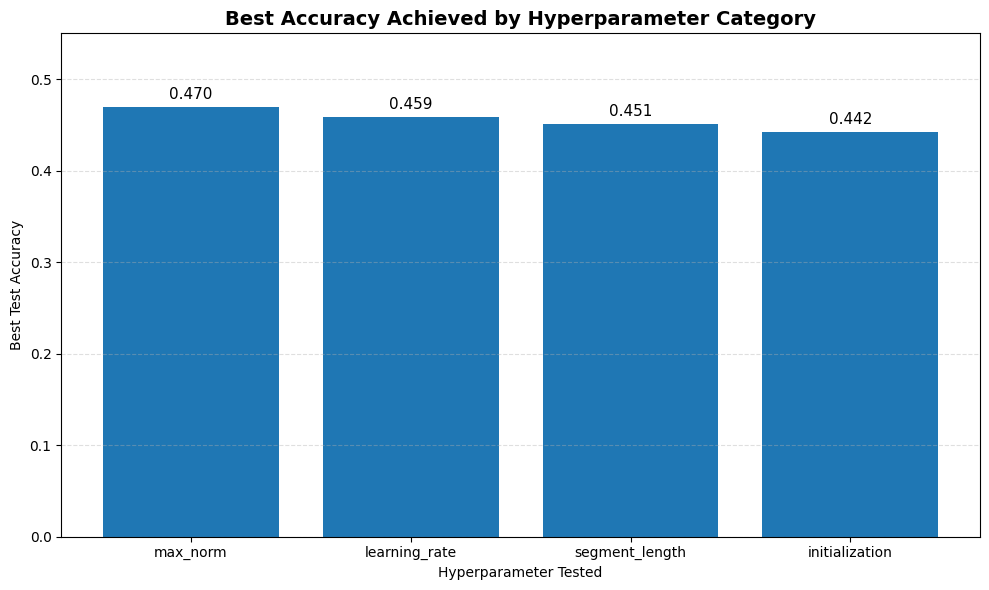

In [20]:

# ============================================================
# CELL 19 — RANK TOP PARAMETERS
# ============================================================


import matplotlib.pyplot as plt

# Compute best score achieved within each parameter group
ranking = summary.groupby("parameter")["best_acc"].max().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(ranking.index, ranking.values)

# Labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Best Accuracy Achieved by Hyperparameter Category", fontsize=14, weight="bold")
plt.xlabel("Hyperparameter Tested")
plt.ylabel("Best Test Accuracy")
plt.ylim(0, 0.55)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Final Experimental Findings

This study evaluated four CNN hyperparameters to determine which had the greatest impact on environmental sound classification performance using the Picszak CNN architecture on the ESC-50 dataset. The parameters tested were:

1. Learning Rate  
2. Weight Initialization  
3. Max-Norm Regularization  
4. Segment Length (input window size)

Each parameter was isolated and tested while keeping the remaining training pipeline unchanged. Performance was measured using best test accuracy over 20 epochs.

---

## Overall Best Hyperparameter Categories

Based on the highest accuracy achieved within each category:

| Rank | Hyperparameter | Best Accuracy |
|------|----------------|--------------|
| 1 | Max-Norm Regularization | 46.96% |
| 2 | Learning Rate | 45.88% |
| 3 | Segment Length | 45.08% |
| 4 | Initialization | 44.23% |

Although max-norm produced the highest single result, impact should also be evaluated by how much changing the parameter altered performance.

---

## Most Impactful Parameters

### 1. Weight Initialization

Weight initialization produced the largest performance gap of all tested variables.

- Xavier Initialization (`kaiming=False`): **44.23%**
- Kaiming Initialization (`kaiming=True`): **8.54%**

This dramatic drop indicates that the Picszak CNN is highly sensitive to initialization strategy. Xavier initialization is substantially better suited for this architecture.

### 2. Segment Length

Changing spectrogram segment length also had a major effect on accuracy.

- Long Segment Variant: **45.08%**
- Short Segment Variant: **27.92%**

This suggests that environmental sound classification benefits strongly from longer temporal context, allowing the CNN to capture richer acoustic patterns.

---

## Secondary Findings

### Learning Rate

Learning rate strongly influenced convergence speed and final accuracy.

- 0.001 → 32.38%
- 0.002 → 36.35%
- 0.005 → 43.63%
- 0.010 → **45.88%**

Higher learning rates performed better in this experiment, with 0.01 producing the strongest result.

### Max-Norm Regularization

Max-norm regularization provided the highest overall score and improved training stability.

- Disabled: 43.46%
- Enabled: **46.96%**

This indicates constraining fully connected layer weights helped generalization.

---

## Final Conclusion

Two different interpretations can be made from these results:

### Highest Absolute Accuracy Gains
1. Max-Norm Regularization  
2. Learning Rate

### Largest Performance Sensitivity (Most Impactful Changes)
1. Weight Initialization  
2. Segment Length

Because the project goal was to identify the parameters with the greatest effect on model behavior, the strongest conclusion is:

## Final Answer

The two most impactful CNN parameters were:

1. **Weight Initialization**  
2. **Segment Length**

These parameters caused the largest changes in accuracy and should be prioritized when optimizing this CNN model.

---

## Best Single Configuration Observed

The strongest individual result in this study was:

- Max-Norm Enabled
- Learning Rate = 0.01
- Long Segment Variant
- Xavier Initialization

This combination would be the recommended direction for future tuning experiments.